STEP 1: Data Collection

In [3]:
#import libraries
# Data Handling
import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load dataset
jobdata = pd.read_csv('/content/HR_Job_Placement_Dataset.csv')

In [5]:
jobdata.head()

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status
0,27,Male,65.061656,83.842578,75.856526,Computer Science,58.221909,89.566305,64.474484,79.548913,...,5.805850,Tier 3,Not Matched,Medium,Not Required,15.0,No,18.0,Not Willing,Not Placed
1,24,Male,67.885626,64.973305,73.093588,Electronics,71.927978,54.591971,61.077306,73.316134,...,10.807739,Tier 1,Matched,High,Required,0.0,NaN,NaN,Not Willing,Not Placed
2,33,Female,73.892471,68.834121,90.196460,Information Technology,72.445041,58.587088,79.494739,75.466980,...,5.476839,Tier 3,Not Matched,Low,Not Required,0.0,No,3.0,Not Willing,Placed
3,31,Male,74.145568,76.255126,75.586731,Mechanical,78.855676,61.022065,53.740386,73.676449,...,9.980580,Tier 2,Matched,Low,Not Required,0.0,Yes,6.0,NaN,Not Placed
4,28,Male,60.475937,65.786336,80.801010,Information Technology,68.286776,65.713731,61.438314,88.994847,...,8.921233,Tier 2,Matched,Medium,Not Required,0.0,No,3.0,Willing,Not Placed


STEP 2: Data Understanding

In [6]:
#check dataset size
jobdata.shape

(51500, 26)

In [7]:
#Data Types Validation
jobdata.dtypes

,0
age_years,int64
gender,object
ssc_percentage,float64
hsc_percentage,float64
degree_percentage,float64
degree_specialization,object
technical_score,float64
aptitude_score,float64
communication_score,float64
skills_match_percentage,float64


In [8]:
jobdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51500 entries, 0 to 51499
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age_years                  51500 non-null  int64  
 1   gender                     51500 non-null  object 
 2   ssc_percentage             48919 non-null  float64
 3   hsc_percentage             49435 non-null  float64
 4   degree_percentage          51500 non-null  float64
 5   degree_specialization      51500 non-null  object 
 6   technical_score            51500 non-null  float64
 7   aptitude_score             51500 non-null  float64
 8   communication_score        51500 non-null  float64
 9   skills_match_percentage    51500 non-null  float64
 10  certifications_count       51500 non-null  int64  
 11  internship_experience      51500 non-null  object 
 12  years_of_experience        51500 non-null  int64  
 13  career_switch_willingness  43034 non-null  obj

In [9]:
#Sample Record Inspection
jobdata.head()

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status
0,27,Male,65.061656,83.842578,75.856526,Computer Science,58.221909,89.566305,64.474484,79.548913,...,5.805850,Tier 3,Not Matched,Medium,Not Required,15.0,No,18.0,Not Willing,Not Placed
1,24,Male,67.885626,64.973305,73.093588,Electronics,71.927978,54.591971,61.077306,73.316134,...,10.807739,Tier 1,Matched,High,Required,0.0,NaN,NaN,Not Willing,Not Placed
2,33,Female,73.892471,68.834121,90.196460,Information Technology,72.445041,58.587088,79.494739,75.466980,...,5.476839,Tier 3,Not Matched,Low,Not Required,0.0,No,3.0,Not Willing,Placed
3,31,Male,74.145568,76.255126,75.586731,Mechanical,78.855676,61.022065,53.740386,73.676449,...,9.980580,Tier 2,Matched,Low,Not Required,0.0,Yes,6.0,NaN,Not Placed
4,28,Male,60.475937,65.786336,80.801010,Information Technology,68.286776,65.713731,61.438314,88.994847,...,8.921233,Tier 2,Matched,Medium,Not Required,0.0,No,3.0,Willing,Not Placed


In [10]:
#Sample Record Inspection
jobdata.tail()

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status
51495,24,Female,65.747180,72.063946,72.247881,Electronics,55.923057,73.208032,69.108895,63.992488,...,6.315211,Tier 1,Matched,Low,Required,0.0,No,3.0,NaN,Not Placed
51496,22,Male,61.921459,66.729203,55.000000,Others,69.525121,70.245612,54.959868,88.514232,...,8.655391,Tier 1,Matched,Medium,Not Required,60.0,No,0.0,Not Willing,Placed
51497,30,Male,75.578202,75.717623,75.048301,Information Technology,73.073239,58.870416,71.219454,79.326789,...,11.538547,Tier 1,Matched,High,Not Required,0.0,No,12.0,NaN,Placed
51498,29,Female,77.327209,56.629227,69.735374,Mechanical,48.270078,61.171900,71.650243,76.318681,...,9.617279,Tier 2,Matched,Medium,Not Required,0.0,Yes,0.0,Willing,Not Placed
51499,26,Female,60.228166,73.374538,70.198897,Information Technology,76.417668,77.979750,50.369813,88.475880,...,6.346281,Tier 3,NaN,Medium,Not Required,60.0,No,0.0,Not Willing,Placed


In [11]:
#Null Value Distribution Analysis
#check total number of missing values in the entire dataset
jobdata.isnull().sum().sum()

np.int64(47290)

In [12]:
#missing value count per column
jobdata.isnull().sum()

,0
age_years,0
gender,0
ssc_percentage,2581
hsc_percentage,2065
degree_percentage,0
degree_specialization,0
technical_score,0
aptitude_score,0
communication_score,0
skills_match_percentage,0


In [13]:
#Shows only columns that actually contain missing values
#(Excludes clean columns)
jobdata.isnull().sum()[jobdata.isnull().sum() > 0]

,0
ssc_percentage,2581
hsc_percentage,2065
career_switch_willingness,8466
relevant_experience,8426
job_role_match,6131
notice_period_days,1582
layoff_history,8467
employment_gap_months,1097
relocation_willingness,8475


In [14]:
#percentage of missing values per column
(jobdata.isnull().sum() / len(jobdata)) * 100

,0
age_years,0.000000
gender,0.000000
ssc_percentage,5.011650
hsc_percentage,4.009709
degree_percentage,0.000000
degree_specialization,0.000000
technical_score,0.000000
aptitude_score,0.000000
communication_score,0.000000
skills_match_percentage,0.000000


Explanation:
I used isnull() to detect missing values.
I calculated total missing values, column-wise missing values, filtered columns with missing data, and computed missing percentage to determine the appropriate data cleaning strategy.

In [15]:
#Statistics summary
jobdata.describe()

,age_years,ssc_percentage,hsc_percentage,degree_percentage,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,years_of_experience,previous_ctc_lpa,expected_ctc_lpa,notice_period_days,employment_gap_months
count,51500.000000,48919.000000,49435.000000,51500.000000,51500.000000,51500.000000,51500.000000,51500.000000,51500.000000,51500.000000,51500.000000,51500.000000,49918.000000,50403.000000
mean,27.505456,70.002505,72.060636,74.010825,68.027499,64.005715,66.106692,73.937491,1.400136,1.494117,4.844616,8.002649,20.095457,3.056187
std,4.025385,7.976314,7.916654,6.945579,11.855145,9.922397,9.907488,11.794258,1.184387,1.375508,2.125294,3.133792,24.852660,4.431784
min,21.000000,50.000000,50.000000,55.000000,40.000000,40.000000,45.000000,45.000000,0.000000,0.000000,1.000000,3.000000,0.000000,0.000000
25%,24.000000,64.574733,66.720058,69.305041,59.935988,57.204237,59.252271,65.851924,1.000000,0.000000,3.325635,5.672655,0.000000,0.000000
50%,27.000000,69.971210,72.014383,73.998187,67.986042,63.972079,66.033268,74.001772,1.000000,1.000000,4.807598,7.857337,15.000000,0.000000
75%,31.000000,75.389057,77.389894,78.707827,76.049235,70.727134,72.840985,82.112773,2.000000,2.000000,6.297570,10.093509,30.000000,6.000000
max,34.000000,95.000000,95.000000,95.000000,100.000000,100.000000,100.000000,100.000000,8.000000,5.000000,13.844566,26.524634,90.000000,18.000000


Exploratory Data Analysis (EDA)(before Data cleaning)

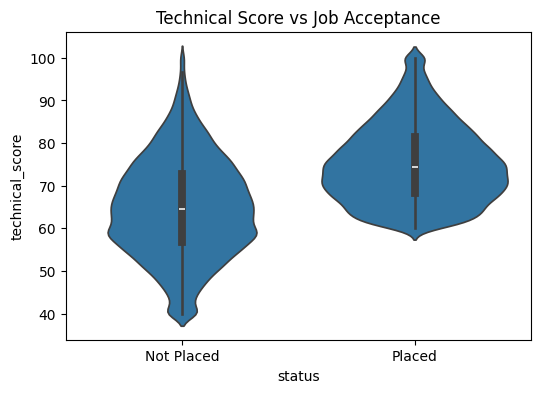

In [16]:
#1️⃣ Interview Score vs Job Acceptance

#Interview performance features:
#technical_score
#aptitude_score
#communication_score

#Technical Score vs Job Acceptance
plt.figure(figsize=(6,4))
sns.violinplot(x="status", y="technical_score", data=jobdata)
plt.title("Technical Score vs Job Acceptance")
plt.show()

insight

The violin plot shows that placed candidates generally have higher technical scores compared to non-placed candidates. While higher scores improve placement chances, the overlap between groups indicates that other factors such as communication skills, experience, and skills match also influence job acceptance.

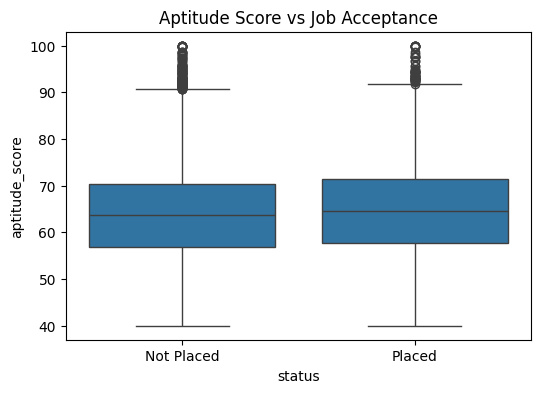

In [17]:
#Aptitude Score vs Job Acceptance
plt.figure(figsize=(6,4))
sns.boxplot(x="status", y="aptitude_score", data=jobdata)
plt.title("Aptitude Score vs Job Acceptance")
plt.show()

Insight

The median aptitude score is higher for placed candidates.

This indicates that analytical and problem-solving ability may influence placement outcomes.

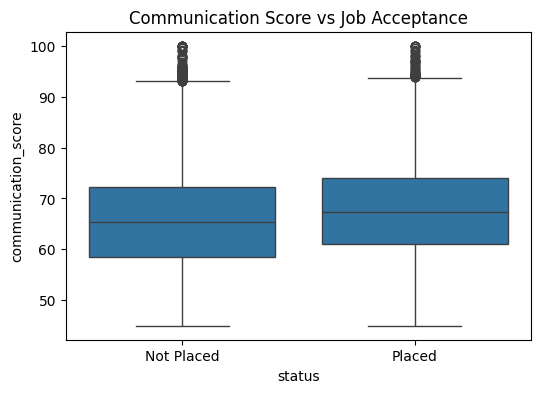

In [18]:
#Communication Score vs Job Acceptance
plt.figure(figsize=(6,4))
sns.boxplot(x="status", y="communication_score", data=jobdata)
plt.title("Communication Score vs Job Acceptance")
plt.show()

Insight

Placed candidates tend to have slightly higher communication scores.

This implies that communication skills may contribute to better interview performance and placement chances.

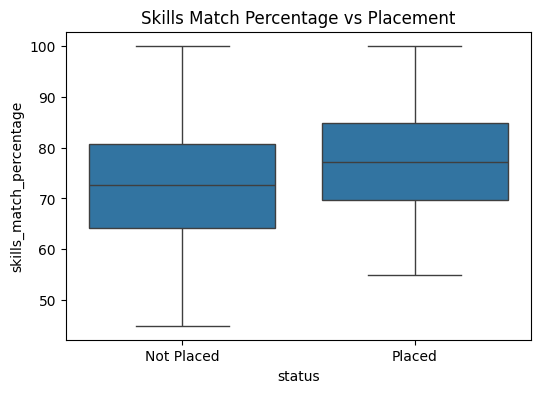

In [19]:
#Skills Match Percentage vs Placement
plt.figure(figsize=(6,4))
sns.boxplot(x="status", y="skills_match_percentage", data=jobdata)
plt.title("Skills Match Percentage vs Placement")
plt.show()

Insight

Candidates with higher skills match percentages are more likely to be placed.

This suggests that alignment between candidate skills and job requirements strongly affects placement success.

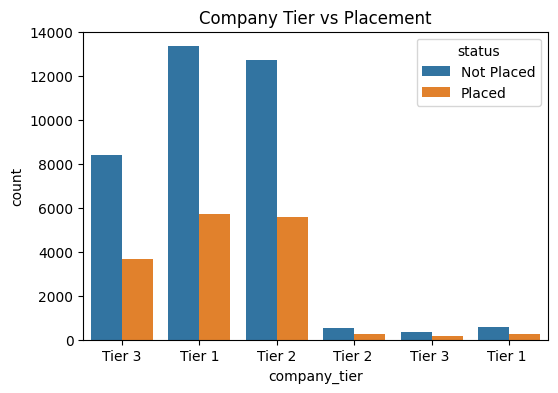

In [20]:
#Company Tier vs Placement
plt.figure(figsize=(6,4))
sns.countplot(x="company_tier", hue="status", data=jobdata)
plt.title("Company Tier vs Placement")
plt.show()

Insight

Certain company tiers recruit more candidates than others.

This indicates that placement opportunities may vary depending on company tier preferences and recruitment capacity.

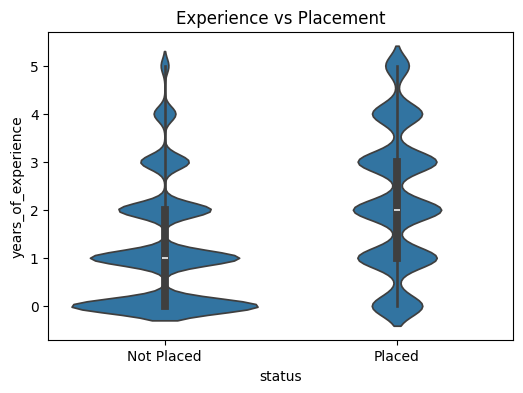

In [21]:
#Experience vs Placement

plt.figure(figsize=(6,4))
sns.violinplot(x="status", y="years_of_experience", data=jobdata)
plt.title("Experience vs Placement")
plt.show()

Insight

The violin plot shows that placed candidates tend to have slightly higher years of experience compared to non-placed candidates. However, the overlap between groups indicates that experience alone does not determine placement success.

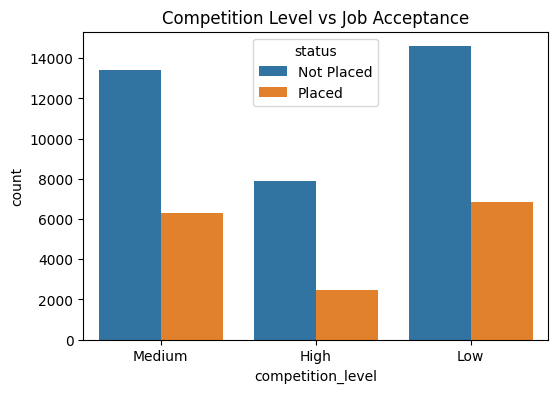

In [22]:
#Competition Level vs Job Acceptance
plt.figure(figsize=(6,4))
sns.countplot(x="competition_level", hue="status", data=jobdata)
plt.title("Competition Level vs Job Acceptance")
plt.show()

Insight

Placement rates appear lower when competition levels are higher.

This indicates that market competition may affect the probability of job acceptance.

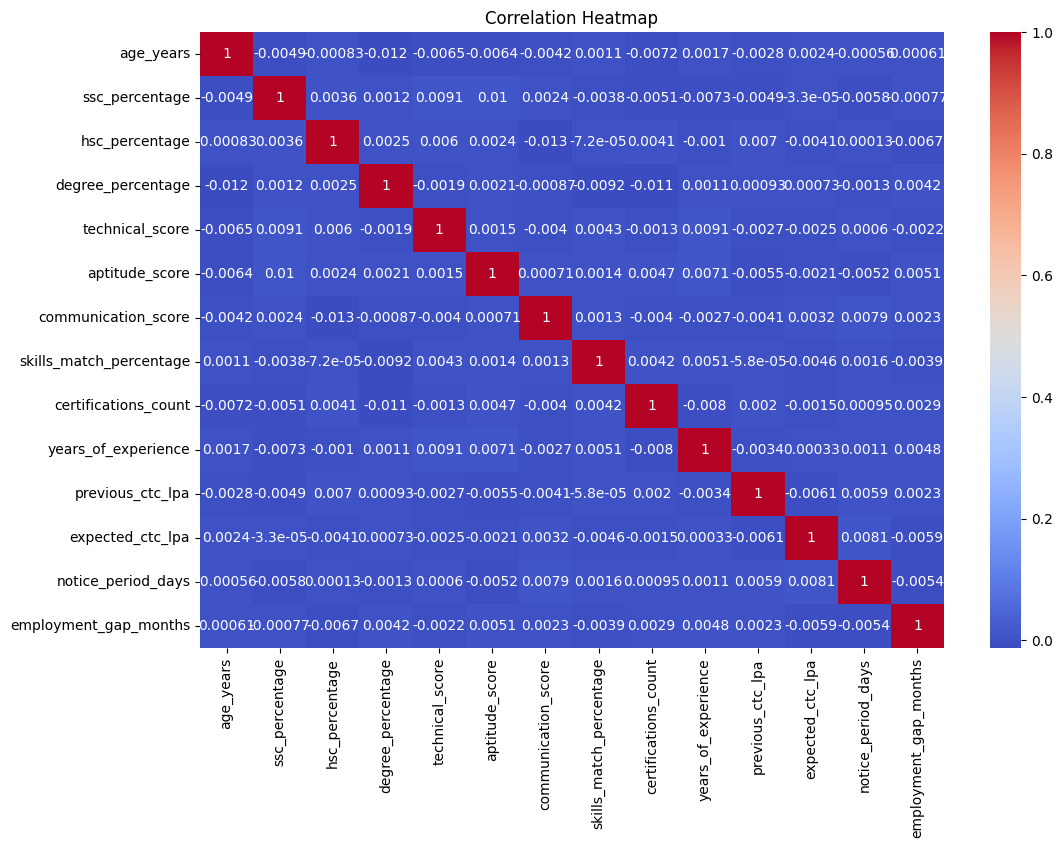

In [23]:
#Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(jobdata.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Insight

The correlation heatmap shows very weak relationships among most features, indicating that the variables are largely independent. This suggests low multicollinearity, which is beneficial for building reliable machine learning models.

STEP 3: Data Cleaning & Preprocessing

In [24]:
# Select numerical columns
numerical_columns = jobdata.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Columns:")
print(numerical_columns)

Numerical Columns:
Index(['age_years', 'ssc_percentage', 'hsc_percentage', 'degree_percentage',
       'technical_score', 'aptitude_score', 'communication_score',
       'skills_match_percentage', 'certifications_count',
       'years_of_experience', 'previous_ctc_lpa', 'expected_ctc_lpa',
       'notice_period_days', 'employment_gap_months'],
      dtype='object')


In [25]:
print("Number of Numerical Columns:", len(numerical_columns))

Number of Numerical Columns: 14


In [26]:
# Select categorical columns
categorical_columns = jobdata.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['gender', 'degree_specialization', 'internship_experience',
       'career_switch_willingness', 'relevant_experience', 'company_tier',
       'job_role_match', 'competition_level', 'bond_requirement',
       'layoff_history', 'relocation_willingness', 'status'],
      dtype='object')


In [27]:
print("Number of Categorical Columns:", len(categorical_columns))

Number of Categorical Columns: 12


In [28]:
# 5. Check duplicate count
jobdata.duplicated().sum()


np.int64(1376)

In [29]:
# 6. Check unique values in important categorical columns
jobdata["gender"].unique()
jobdata["internship_experience"].unique()
jobdata["company_tier"].unique()


array(['Tier 3', 'Tier 1', 'Tier 2', 'Tier 2 ', 'Tier 3 ', 'Tier 1 '],
      dtype=object)

In [30]:
# 7. Target variable distribution
jobdata["status"].value_counts()

,count
status,
Not Placed,35921
Placed,15579


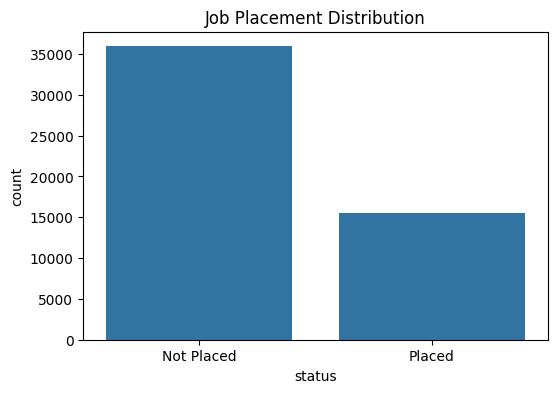

In [31]:
#Target variable distribution
plt.figure(figsize=(6,4))
sns.countplot(x="status", data=jobdata)
plt.title("Job Placement Distribution")
plt.show()

Explanation

The distribution shows that the number of not placed candidates is significantly higher than placed candidates, indicating a class imbalance in the dataset. This imbalance suggests that job placement is competitive and may require handling during machine learning modeling.

In [32]:
#Handling Missing Values
#Using Skewness Value
#Check skewness only for numerical columns
numerical_cols = jobdata.select_dtypes(include=['int64', 'float64'])
numerical_cols.skew()

,0
age_years,-0.001574
ssc_percentage,0.047471
hsc_percentage,0.007296
degree_percentage,0.023136
technical_score,0.034879
aptitude_score,0.052581
communication_score,0.102563
skills_match_percentage,-0.047056
certifications_count,0.851307
years_of_experience,0.706908


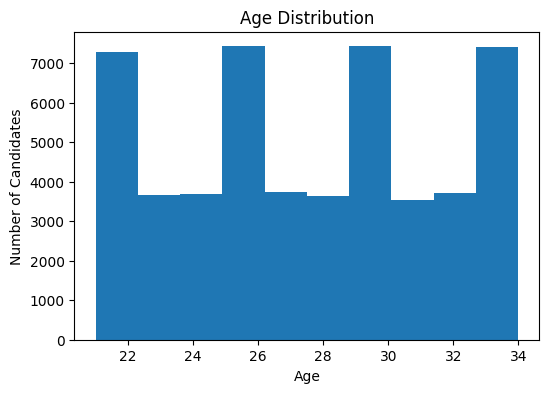

In [33]:
#Using Histogram (Visualization)
plt.figure(figsize=(6,4))
plt.hist(jobdata['age_years'], bins=10)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Candidates')
plt.show()

Insight

The age distribution shows that most candidates belong to the younger age group, indicating that the dataset mainly represents early-career job seekers. Older age groups appear less frequently, suggesting the recruitment focus is on entry-level candidates.



Key preprocessing steps include:
Handling missing values using mean, median, or mode


In [34]:
# Mean fill
cols_mean = ['age_years','ssc_percentage','hsc_percentage',
             'degree_percentage','technical_score',
             'aptitude_score','communication_score',
             'skills_match_percentage','previous_ctc_lpa']

for col in cols_mean:
    jobdata[col] = jobdata[col].fillna(jobdata[col].mean())

In [35]:
# Median fill
cols_median = ['certifications_count','years_of_experience',
               'expected_ctc_lpa','notice_period_days',
               'employment_gap_months']

for col in cols_median:
    jobdata[col] = jobdata[col].fillna(jobdata[col].median())

Explanation:

The data is normally distributed I use mean imputation,Some of these  skewed I prefer median because median is less affected by outliers."

In [36]:
#mode fill
cols_mode = ['career_switch_willingness',
             'relevant_experience',
             'job_role_match',
             'layoff_history',
             'relocation_willingness']

for col in cols_mode:
    jobdata[col] = jobdata[col].fillna(jobdata[col].mode()[0])

Explanation:

For categorical features I used mode imputation because it replaces missing values with the most frequent category.

In [37]:
jobdata.isnull().sum()

,0
age_years,0
gender,0
ssc_percentage,0
hsc_percentage,0
degree_percentage,0
degree_specialization,0
technical_score,0
aptitude_score,0
communication_score,0
skills_match_percentage,0


In [38]:
jobdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51500 entries, 0 to 51499
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age_years                  51500 non-null  int64  
 1   gender                     51500 non-null  object 
 2   ssc_percentage             51500 non-null  float64
 3   hsc_percentage             51500 non-null  float64
 4   degree_percentage          51500 non-null  float64
 5   degree_specialization      51500 non-null  object 
 6   technical_score            51500 non-null  float64
 7   aptitude_score             51500 non-null  float64
 8   communication_score        51500 non-null  float64
 9   skills_match_percentage    51500 non-null  float64
 10  certifications_count       51500 non-null  int64  
 11  internship_experience      51500 non-null  object 
 12  years_of_experience        51500 non-null  int64  
 13  career_switch_willingness  51500 non-null  obj

Checking outliers

In [39]:
#identify numerical columns
num_cols = jobdata.select_dtypes(include=['int64','float64']).columns
print(num_cols)

Index(['age_years', 'ssc_percentage', 'hsc_percentage', 'degree_percentage',
       'technical_score', 'aptitude_score', 'communication_score',
       'skills_match_percentage', 'certifications_count',
       'years_of_experience', 'previous_ctc_lpa', 'expected_ctc_lpa',
       'notice_period_days', 'employment_gap_months'],
      dtype='object')


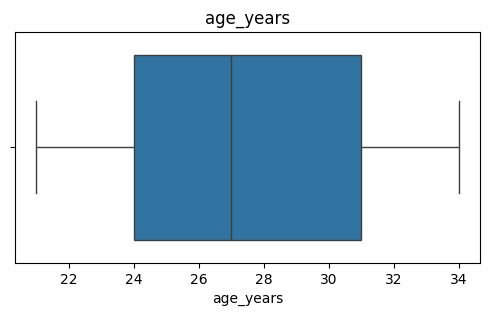

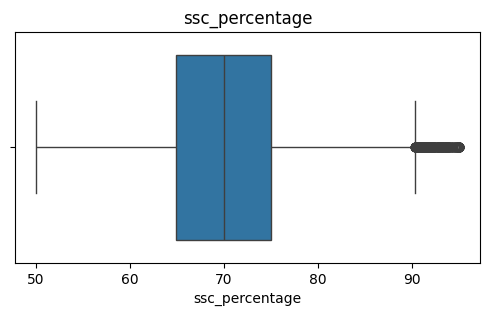

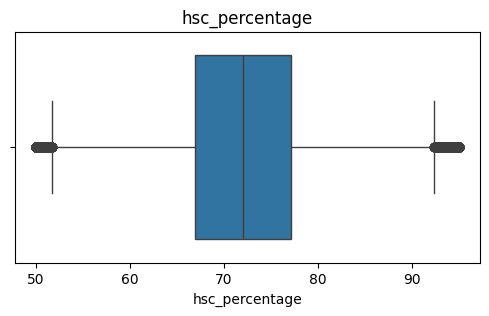

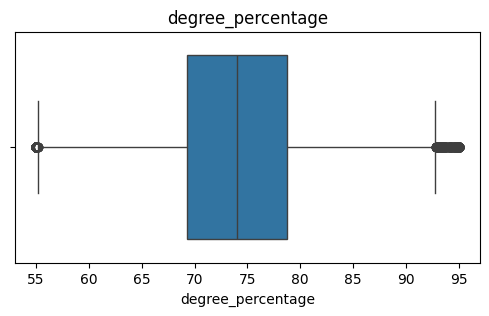

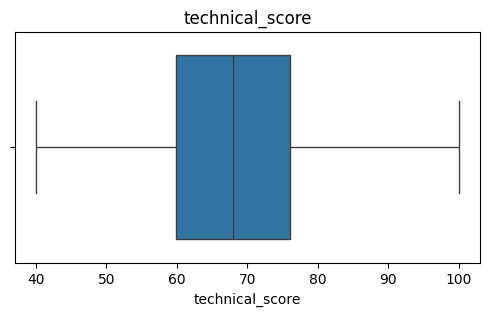

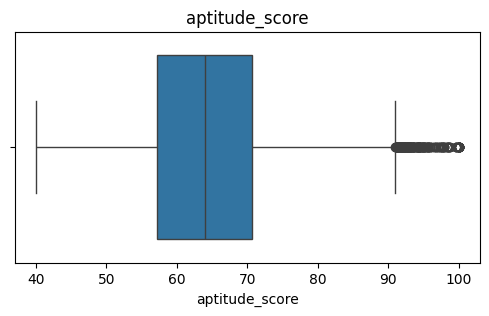

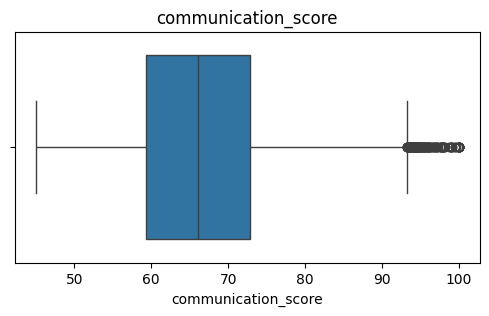

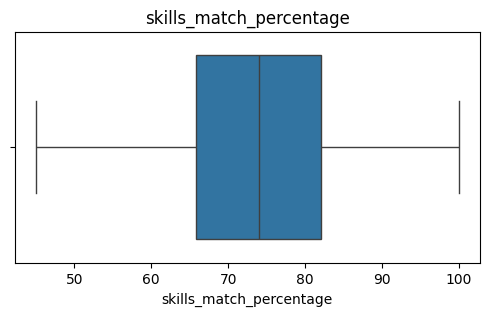

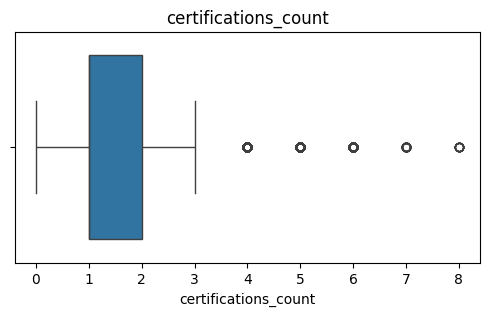

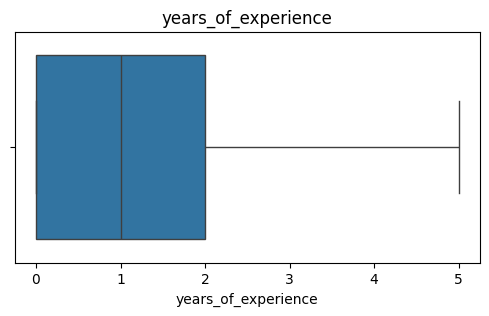

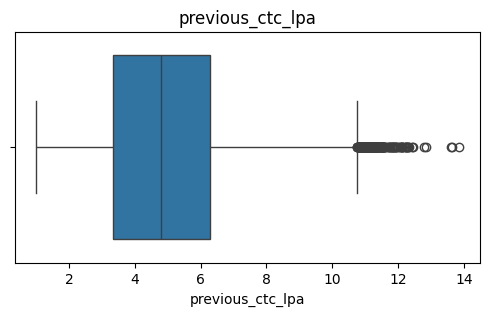

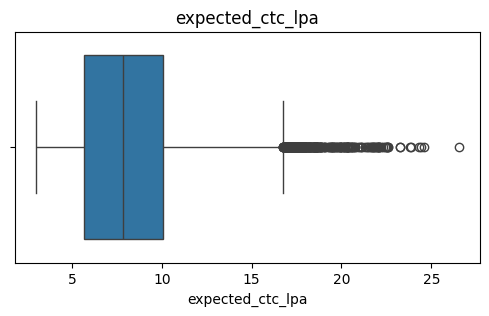

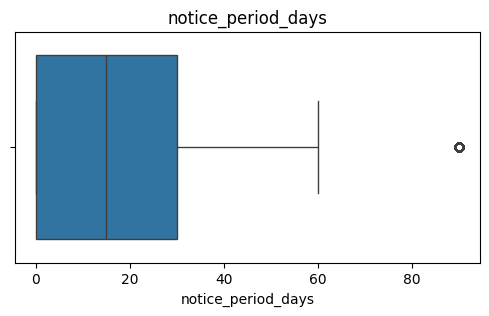

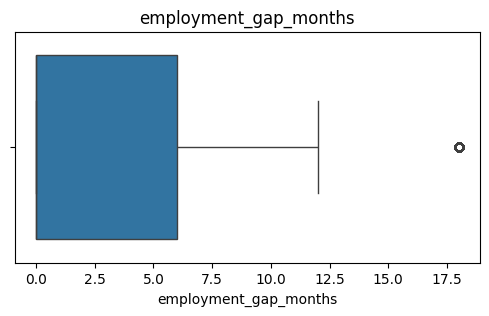

In [40]:
#Boxplot to visually check outliers

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=jobdata[col])
    plt.title(col)
    plt.show()

In [41]:
#check outliers count
num_cols = jobdata.select_dtypes(include=['int64','float64']).columns

for col in num_cols:

    Q1 = jobdata[col].quantile(0.25)
    Q3 = jobdata[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = jobdata[(jobdata[col] < lower) | (jobdata[col] > upper)]

    print(col, ":", len(outliers))

age_years : 0
ssc_percentage : 273
hsc_percentage : 541
degree_percentage : 376
technical_score : 0
aptitude_score : 185
communication_score : 165
skills_match_percentage : 0
certifications_count : 2777
years_of_experience : 0
previous_ctc_lpa : 184
expected_ctc_lpa : 301
notice_period_days : 2547
employment_gap_months : 1565


In [42]:
#Capping Only These Columns
cols_cap = [
'certifications_count',
'previous_ctc_lpa',
'expected_ctc_lpa',
'notice_period_days',
'employment_gap_months'
]

for col in cols_cap:

    Q1 = jobdata[col].quantile(0.25)
    Q3 = jobdata[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    jobdata[col] = jobdata[col].clip(lower, upper)

In [43]:
#checking outliers after capping
import numpy as np

num_cols = jobdata.select_dtypes(include=np.number).columns

for col in num_cols:
    Q1 = jobdata[col].quantile(0.25)
    Q3 = jobdata[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = jobdata[(jobdata[col] < lower) | (jobdata[col] > upper)]

    print(col, ":", outliers.shape[0])

age_years : 0
ssc_percentage : 273
hsc_percentage : 541
degree_percentage : 376
technical_score : 0
aptitude_score : 185
communication_score : 165
skills_match_percentage : 0
certifications_count : 0
years_of_experience : 0
previous_ctc_lpa : 0
expected_ctc_lpa : 0
notice_period_days : 0
employment_gap_months : 0


Explanation

Important columns are cleaned

Remaining outliers are valid score variations

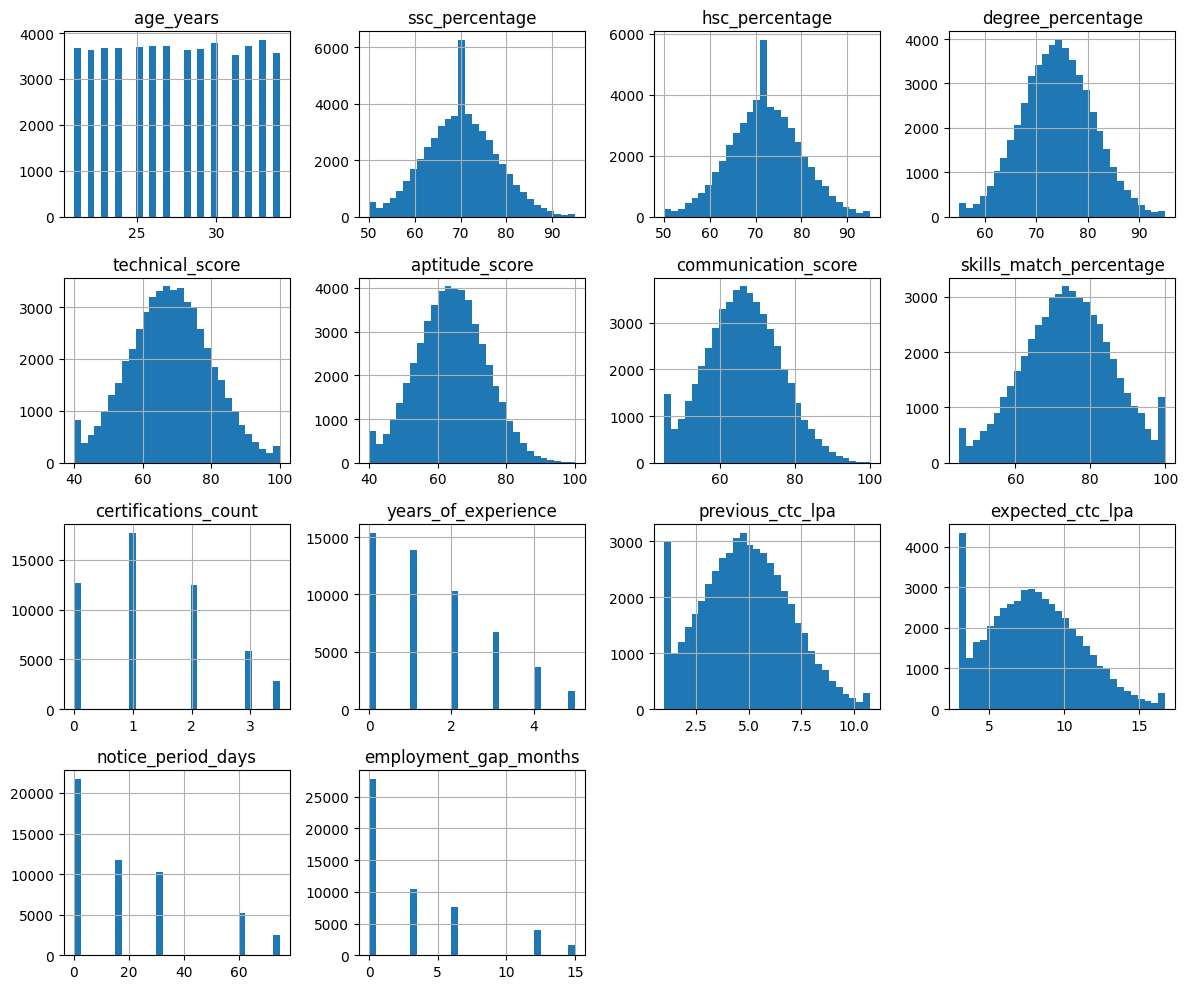

In [44]:
#Numerical feature distribution
#Even after capping, check how features are spread

numerical_cols = ['age_years','ssc_percentage','hsc_percentage','degree_percentage',
                  'technical_score','aptitude_score','communication_score',
                  'skills_match_percentage','certifications_count','years_of_experience',
                  'previous_ctc_lpa','expected_ctc_lpa','notice_period_days','employment_gap_months']

jobdata[numerical_cols].hist(figsize=(12,10), bins=30)
plt.tight_layout()
plt.show()

In [45]:
#check duplicates
jobdata.duplicated().sum()

np.int64(1376)

In [46]:
#Remove Duplicates
jobdata = jobdata.drop_duplicates()

In [47]:
#verify again
jobdata.duplicated().sum()

np.int64(0)

In [48]:
#After removing duplicates, check dataset shape:
jobdata.shape

(50124, 26)

In [49]:
jobdata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50124 entries, 0 to 51497
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age_years                  50124 non-null  int64  
 1   gender                     50124 non-null  object 
 2   ssc_percentage             50124 non-null  float64
 3   hsc_percentage             50124 non-null  float64
 4   degree_percentage          50124 non-null  float64
 5   degree_specialization      50124 non-null  object 
 6   technical_score            50124 non-null  float64
 7   aptitude_score             50124 non-null  float64
 8   communication_score        50124 non-null  float64
 9   skills_match_percentage    50124 non-null  float64
 10  certifications_count       50124 non-null  float64
 11  internship_experience      50124 non-null  object 
 12  years_of_experience        50124 non-null  int64  
 13  career_switch_willingness  50124 non-null  object 


Correcting Inconsistent Categorical Labels

In [50]:
cat_cols = jobdata.select_dtypes(include='object').columns

for col in cat_cols:
    print(col, ":", jobdata[col].unique())

gender : ['Male' 'Female' 'female' 'male']
degree_specialization : ['Computer Science' 'Electronics' 'Information Technology' 'Mechanical'
 'Others']
internship_experience : ['No' 'yes ' 'Yes' ' no']
career_switch_willingness : ['Willing' 'Not Willing']
relevant_experience : ['Relevant' 'Not Relevant']
company_tier : ['Tier 3' 'Tier 1' 'Tier 2' 'Tier 2 ' 'Tier 3 ' 'Tier 1 ']
job_role_match : ['Not Matched' 'Matched']
competition_level : ['Medium' 'High' 'Low']
bond_requirement : ['Not Required' 'Required']
layoff_history : ['No' 'Yes']
relocation_willingness : ['Not Willing' 'Willing']
status : ['Not Placed' 'Placed']


In [51]:
#clean inconsistent labels
cat_cols = jobdata.select_dtypes(include='object').columns

for col in cat_cols:
    jobdata[col] = jobdata[col].str.lower().str.strip()

In [52]:
#check again
for col in cat_cols:
    print(col, ":", jobdata[col].unique())

gender : ['male' 'female']
degree_specialization : ['computer science' 'electronics' 'information technology' 'mechanical'
 'others']
internship_experience : ['no' 'yes']
career_switch_willingness : ['willing' 'not willing']
relevant_experience : ['relevant' 'not relevant']
company_tier : ['tier 3' 'tier 1' 'tier 2']
job_role_match : ['not matched' 'matched']
competition_level : ['medium' 'high' 'low']
bond_requirement : ['not required' 'required']
layoff_history : ['no' 'yes']
relocation_willingness : ['not willing' 'willing']
status : ['not placed' 'placed']


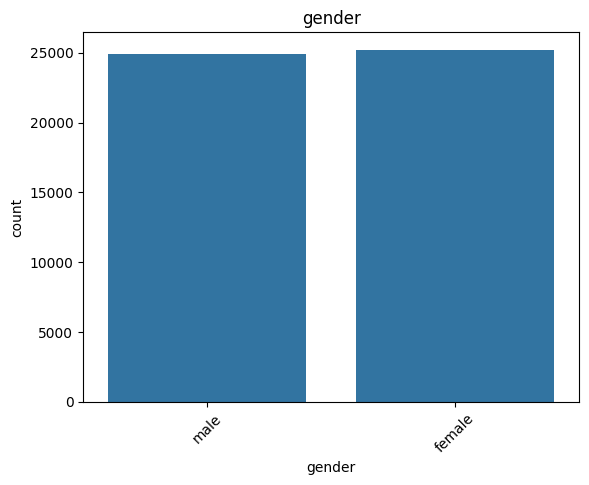

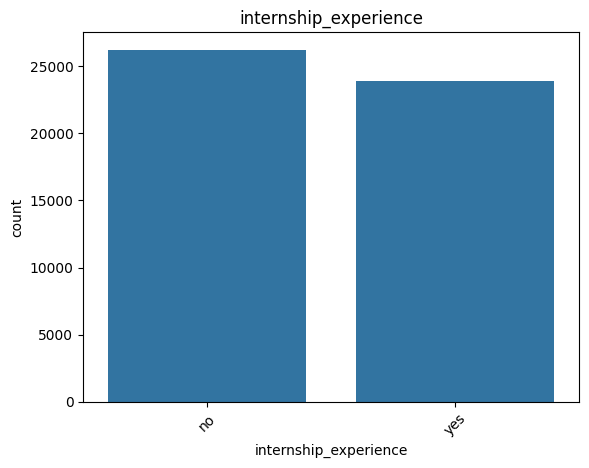

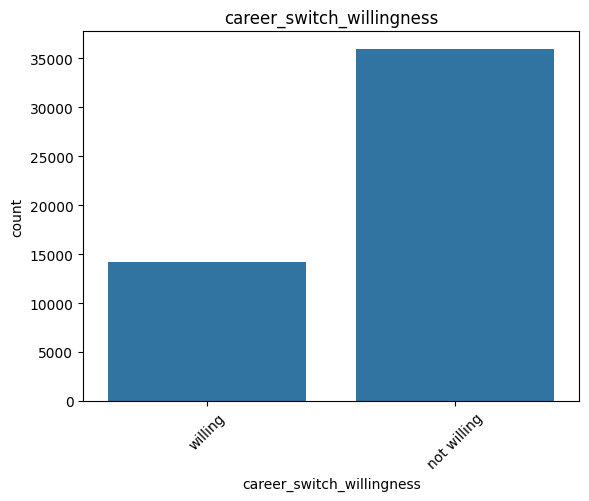

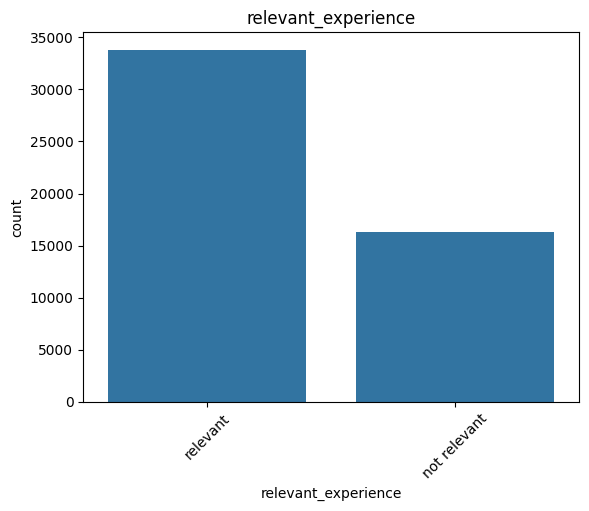

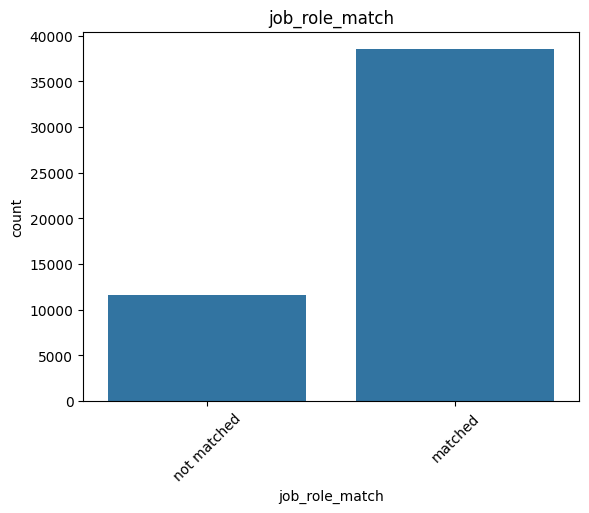

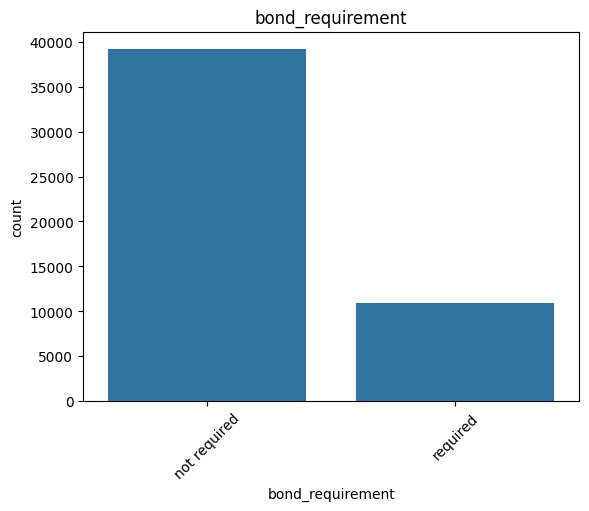

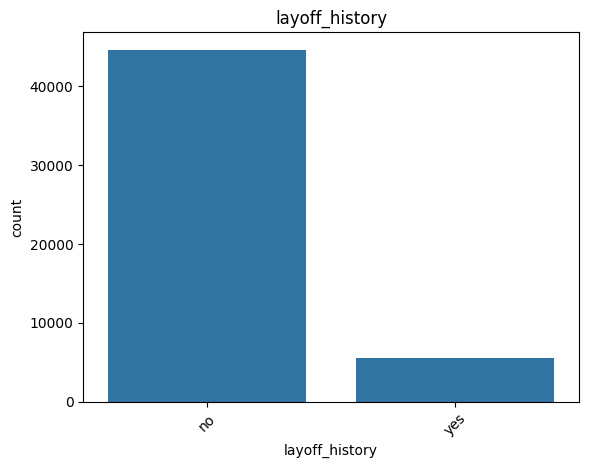

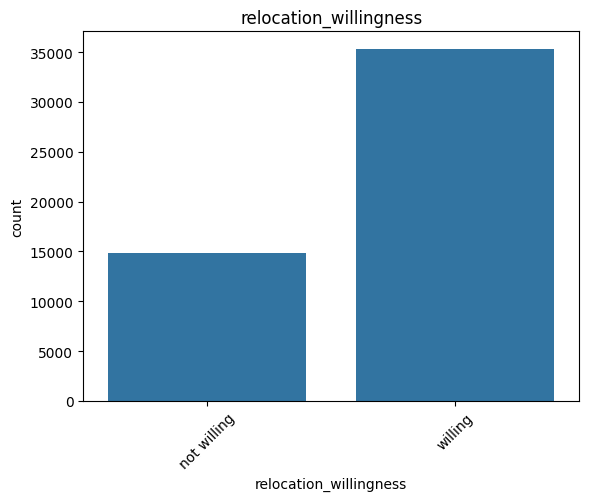

In [53]:
#Categorical feature distribution
categorical_cols = ['gender','internship_experience',
                    'career_switch_willingness','relevant_experience',
                    'job_role_match','bond_requirement',
                    'layoff_history','relocation_willingness']

for col in categorical_cols:
    sns.countplot(x=col, data=jobdata)
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

Ensuring logical consistency across features


Age vs Experience

A person’s experience cannot be greater than age.

In [54]:
(jobdata['years_of_experience'] > jobdata['age_years']).sum()

np.int64(0)

Expected Salary vs Previous Salary

Normally candidates expect same or higher salary.

In [55]:
(jobdata['expected_ctc_lpa'] < jobdata['previous_ctc_lpa']).sum()

np.int64(10595)

In [56]:
#Cap Expected Salary to be ≥ Previous Salary
jobdata['expected_ctc_lpa'] = jobdata[['expected_ctc_lpa', 'previous_ctc_lpa']].max(axis=1)

In [57]:
# Check again if any row has expected salary < previous salary
(jobdata['expected_ctc_lpa'] < jobdata['previous_ctc_lpa']).sum()

np.int64(0)

Notice Period Check

Notice period cannot be negative.

In [58]:
(jobdata['notice_period_days'] < 0).sum()

np.int64(0)

Employment Gap Check

Gap cannot be negative.

In [59]:
(jobdata['employment_gap_months'] < 0).sum()

np.int64(0)

Percentage Columns (0–100 range)

In [60]:
((jobdata['ssc_percentage'] < 0) | (jobdata['ssc_percentage'] > 100)).sum()
((jobdata['hsc_percentage'] < 0) | (jobdata['hsc_percentage'] > 100)).sum()

((jobdata['degree_percentage'] < 0) | (jobdata['degree_percentage'] > 100)).sum()

((jobdata['skills_match_percentage'] < 0) | (jobdata['skills_match_percentage'] > 100)).sum()

np.int64(0)

Certifications Count

Certificates cannot be negative.

In [61]:
(jobdata['certifications_count'] < 0).sum()

np.int64(0)

In [62]:
jobdata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50124 entries, 0 to 51497
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age_years                  50124 non-null  int64  
 1   gender                     50124 non-null  object 
 2   ssc_percentage             50124 non-null  float64
 3   hsc_percentage             50124 non-null  float64
 4   degree_percentage          50124 non-null  float64
 5   degree_specialization      50124 non-null  object 
 6   technical_score            50124 non-null  float64
 7   aptitude_score             50124 non-null  float64
 8   communication_score        50124 non-null  float64
 9   skills_match_percentage    50124 non-null  float64
 10  certifications_count       50124 non-null  float64
 11  internship_experience      50124 non-null  object 
 12  years_of_experience        50124 non-null  int64  
 13  career_switch_willingness  50124 non-null  object 


 Step 4: Exploratory Data Analysis (EDA)
(after cleaning)



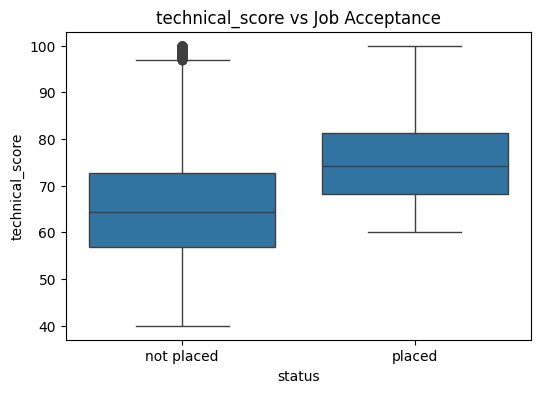

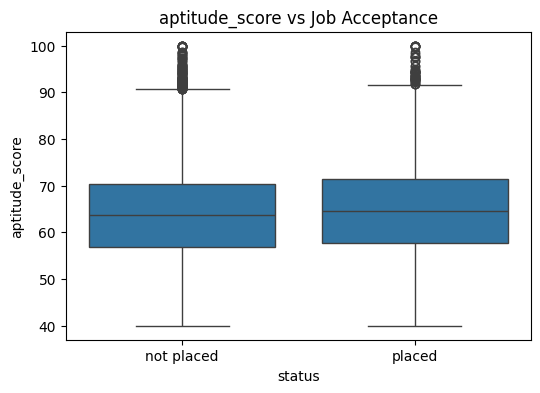

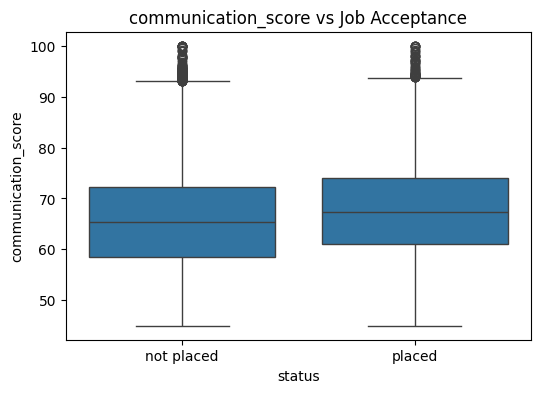

In [63]:
#1️⃣ Interview Score vs Job Acceptance
#Features:
#technical_score
#aptitude_score
#communication_score

scores = ['technical_score','aptitude_score','communication_score']

for col in scores:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='status', y=col, data=jobdata)
    plt.title(f'{col} vs Job Acceptance')
    plt.show()

Insight

Placed candidates generally show higher interview scores compared to not placed candidates.

This indicates that strong interview performance increases placement probability.

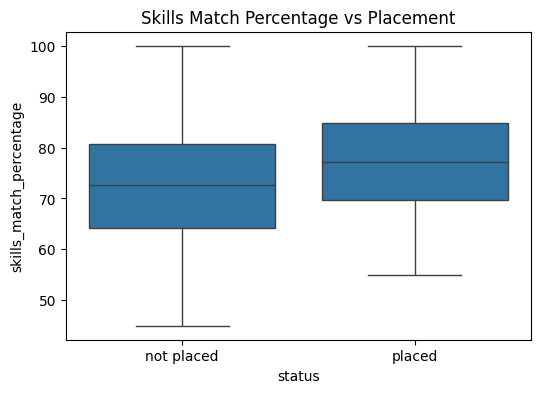

In [64]:
#2️⃣ Skills Match Percentage vs Placement
plt.figure(figsize=(6,4))
sns.boxplot(x='status', y='skills_match_percentage', data=jobdata)
plt.title('Skills Match Percentage vs Placement')
plt.show()

Insight

Placed candidates tend to have higher skills match percentages.

This suggests that alignment between candidate skills and job requirements improves placement chances.

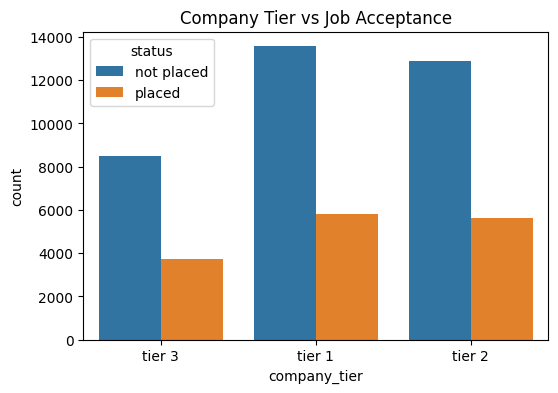

In [65]:
#3️⃣ Company Tier vs Job Acceptance
plt.figure(figsize=(6,4))
sns.countplot(x='company_tier', hue='status', data=jobdata)
plt.title('Company Tier vs Job Acceptance')
plt.show()

Insight

Placement counts vary across company tiers.

Certain tiers appear to hire more candidates, indicating differences in recruitment capacity.

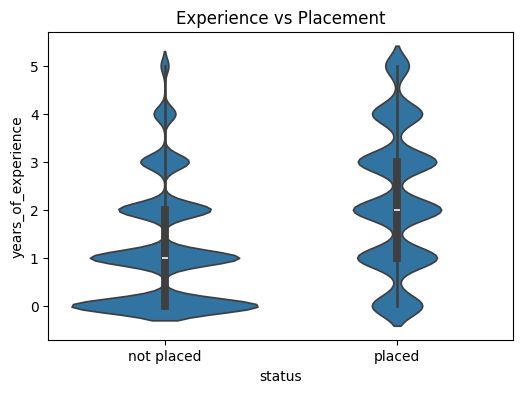

In [66]:
#4️⃣ Experience vs Placement Probability
plt.figure(figsize=(6,4))
sns.violinplot(x='status', y='years_of_experience', data=jobdata)
plt.title('Experience vs Placement')
plt.show()

Insight

Placed candidates tend to have slightly higher experience levels.

However, overlap between groups indicates experience alone does not determine placement.

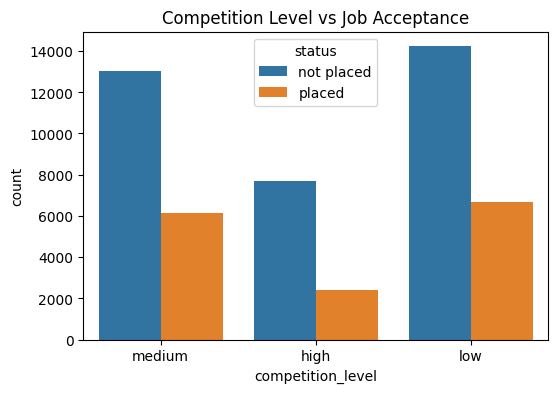

In [67]:
#5️⃣ Competition Level vs Job Acceptance

plt.figure(figsize=(6,4))
sns.countplot(x='competition_level', hue='status', data=jobdata)
plt.title('Competition Level vs Job Acceptance')
plt.show()

Insight

Placement rates appear higher when competition levels are low.

As competition increases, the probability of job acceptance decreases.

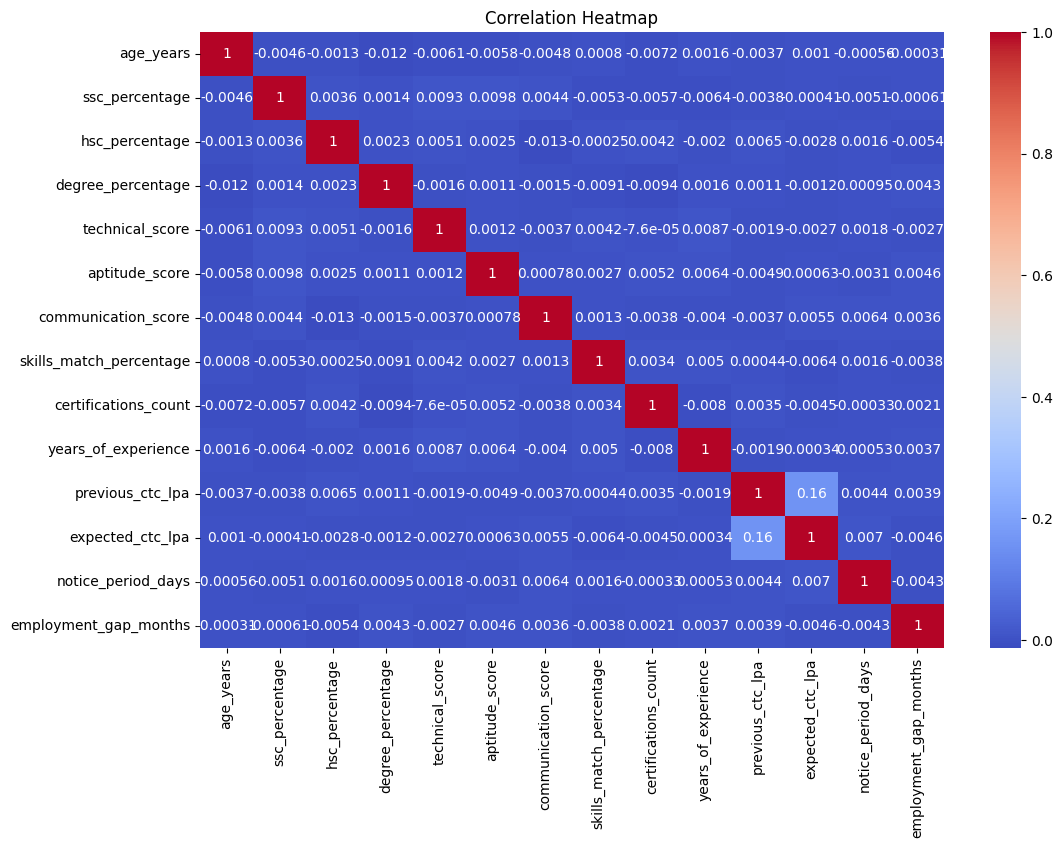

In [68]:
#6️⃣ Correlation Analysis Among Numeric Features
plt.figure(figsize=(12,8))
sns.heatmap(jobdata.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Insight

Most numeric features show weak correlations, indicating they provide independent information.

Low multicollinearity is beneficial for machine learning models.

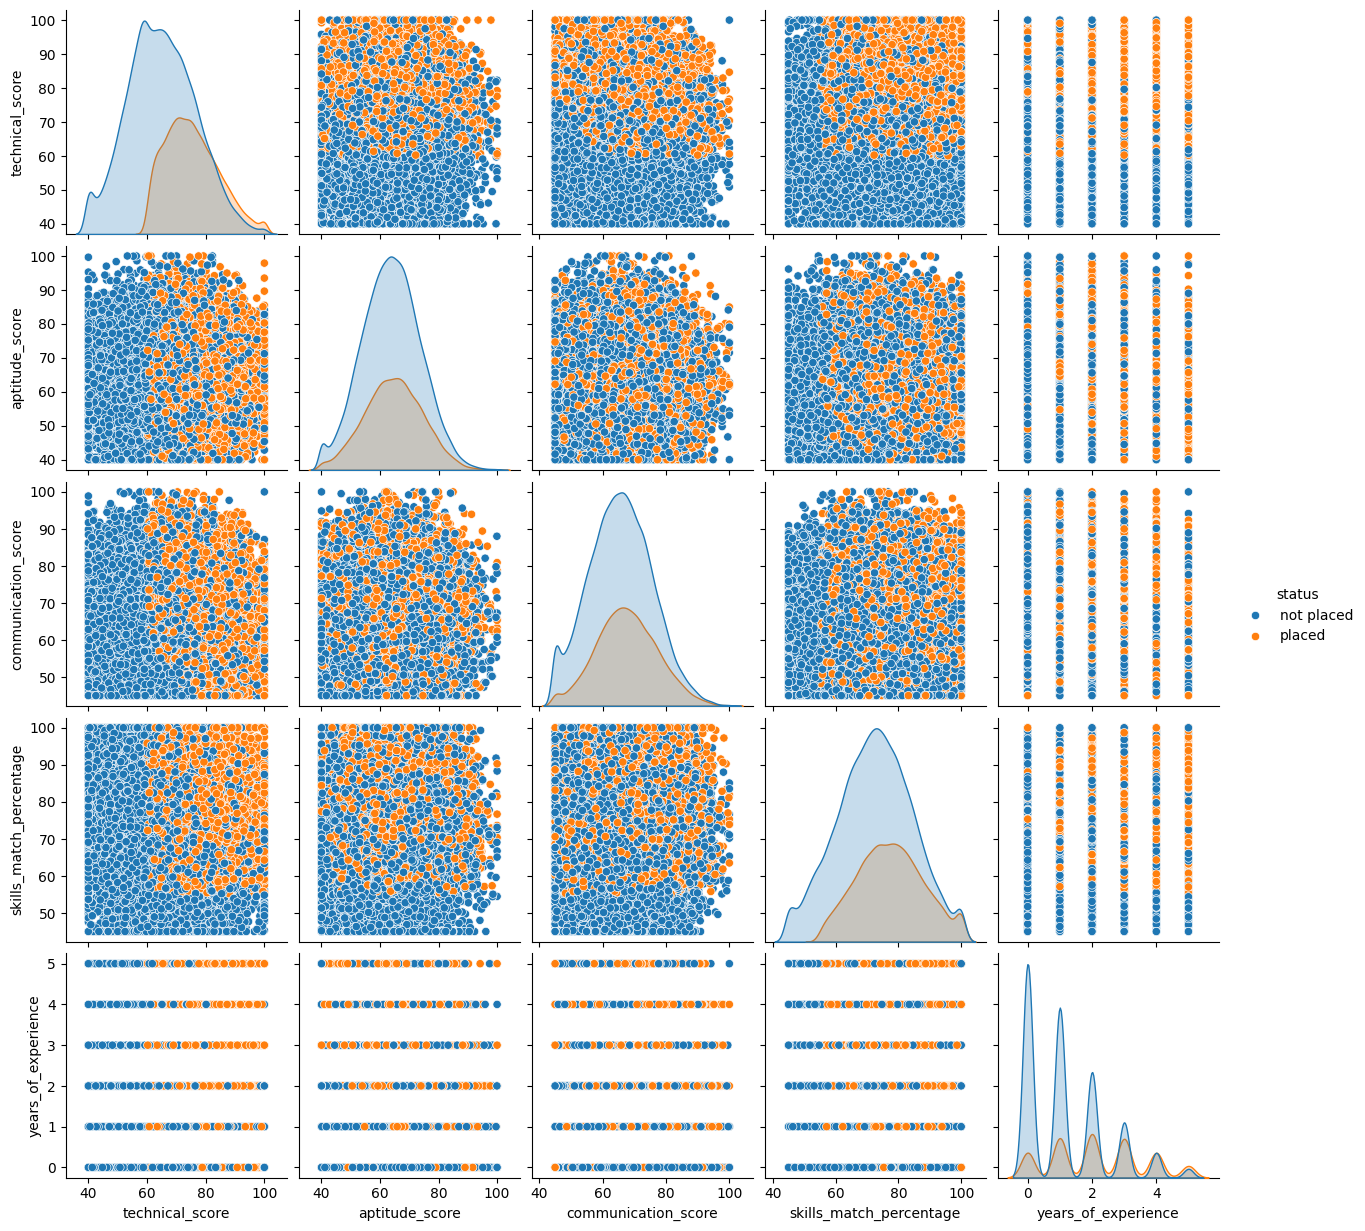

In [69]:
#Pairplot (Relationship Between Important Features)
#This shows relationships between multiple features at once.

important_features = [
    'technical_score',
    'aptitude_score',
    'communication_score',
    'skills_match_percentage',
    'years_of_experience'
]

sns.pairplot(jobdata[important_features + ['status']], hue='status')
plt.show()

Insight

Placed candidates tend to cluster around higher interview scores and skills match percentages.

Some overlap exists, indicating multiple factors influence placement.

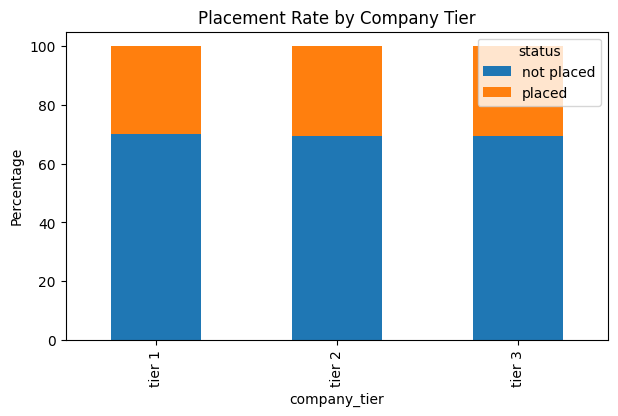

In [70]:
#Placement Rate by Company Tier
#Instead of just counts, show placement percentage per company tier.

placement_rate = pd.crosstab(jobdata['company_tier'], jobdata['status'], normalize='index') * 100

placement_rate.plot(kind='bar', stacked=True, figsize=(7,4))
plt.title('Placement Rate by Company Tier')
plt.ylabel('Percentage')
plt.show()

Insight

Some company tiers show higher placement percentages than others.

This indicates that recruitment intensity differs across company tiers.

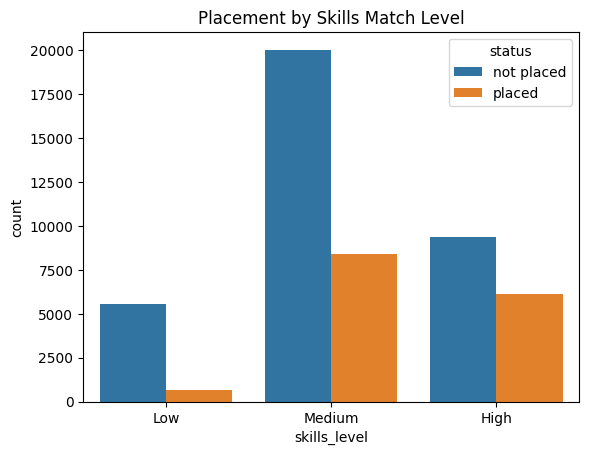

In [71]:
#Placement Rate by Skills Match Level
#First categorize skills into levels.

jobdata['skills_level'] = pd.cut(
    jobdata['skills_match_percentage'],
    bins=[0,60,80,100],
    labels=['Low','Medium','High']
)

sns.countplot(x='skills_level', hue='status', data=jobdata)
plt.title('Placement by Skills Match Level')
plt.show()

Insight

Candidates with high skill match levels show higher placement counts.

This highlights the importance of skill-job alignment in recruitment decisions.

In [72]:
#Placement Rate by Experience Category
#First create experience categories.
jobdata['experience_level'] = pd.cut(
    jobdata['years_of_experience'],
    bins=[0,1,3,10],
    labels=['Fresher','Junior','Senior']
)

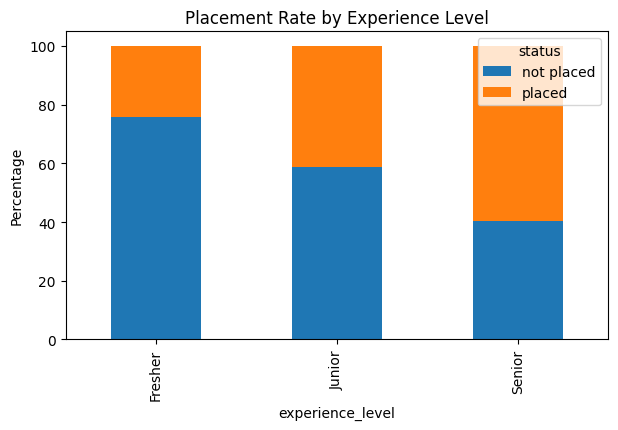

In [73]:
placement_rate = pd.crosstab(
    jobdata['experience_level'],
    jobdata['status'],
    normalize='index'
) * 100

placement_rate.plot(kind='bar', stacked=True, figsize=(7,4))
plt.title("Placement Rate by Experience Level")
plt.ylabel("Percentage")
plt.show()

Insight

Senior candidates show higher placement rates, indicating that experience improves employability.

Freshers have lower placement percentages, suggesting stronger competition for entry-level roles.

EDA over all explanation

Exploratory Data Analysis reveals that interview performance, skills match percentage, and experience significantly influence job placement outcomes. Candidates with higher technical and communication scores, stronger skill alignment, and moderate work experience show higher placement probabilities. Additionally, company tier and competition level impact hiring patterns, while correlation analysis indicates low multicollinearity among numeric features.


🔹 Step 5: Feature Engineering
Derived analytical features include:
Experience category (Fresher / Junior / Senior)

In [74]:
#Experience Category
#You have years_of_experience, so creating categories helps models and dashboards.
jobdata['experience_category'] = pd.cut(
    jobdata['years_of_experience'],
    bins=[0,1,4,10],
    labels=['Fresher','Junior','Senior']
)


This is useful for Companies often evaluate candidates by experience level.

In [75]:
#Academic Performance Band
#You can combine ssc_percentage, hsc_percentage, degree_percentage.

jobdata['academic_avg'] = (
    jobdata['ssc_percentage'] +
    jobdata['hsc_percentage'] +
    jobdata['degree_percentage']
) / 3

jobdata['academic_band'] = pd.cut(
    jobdata['academic_avg'],
    bins=[0,60,75,100],
    labels=['Average','Good','Excellent']
)

This is useful for Creates a single academic performance indicator.

In [76]:
#Skills Match Level (Recommended)
#You already have skills_match_percentage.
jobdata['skills_level'] = pd.cut(
    jobdata['skills_match_percentage'],
    bins=[0,60,80,100],
    labels=['Low','Medium','High']
)

It Helps interpret skills alignment easily.

In [77]:
#Interview Performance Category (Optional)
#You can combine:
#technical_score
#aptitude_score
#communication_score
jobdata['interview_avg'] = (
    jobdata['technical_score'] +
    jobdata['aptitude_score'] +
    jobdata['communication_score']
) / 3

jobdata['interview_level'] = pd.cut(
    jobdata['interview_avg'],
    bins=[0,60,80,100],
    labels=['Low','Medium','High']
)


It Represents overall interview performance.

Encoding categorical variables (Label / One-Hot Encoding)
#Label Encoding
#Label Encoding converts categories into numbers.

In [78]:
#import library
from sklearn.preprocessing import LabelEncoder

In [79]:
#Label Encoding (Binary Columns)

le = LabelEncoder()

cols_label = ['gender','internship_experience','career_switch_willingness',
              'relevant_experience','job_role_match','bond_requirement',
              'layoff_history','relocation_willingness','status']

for col in cols_label:
    jobdata[col] = le.fit_transform(jobdata[col])

One-Hot Encoding

One-Hot Encoding (Multiple Categories)

In [80]:
jobdata = pd.get_dummies(jobdata,
                         columns=['degree_specialization',
                                  'company_tier',
                                  'competition_level'],
                         drop_first=True)

In [81]:
#After encoding check
jobdata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50124 entries, 0 to 51497
Data columns (total 38 columns):
 #   Column                                        Non-Null Count  Dtype   
---  ------                                        --------------  -----   
 0   age_years                                     50124 non-null  int64   
 1   gender                                        50124 non-null  int64   
 2   ssc_percentage                                50124 non-null  float64 
 3   hsc_percentage                                50124 non-null  float64 
 4   degree_percentage                             50124 non-null  float64 
 5   technical_score                               50124 non-null  float64 
 6   aptitude_score                                50124 non-null  float64 
 7   communication_score                           50124 non-null  float64 
 8   skills_match_percentage                       50124 non-null  float64 
 9   certifications_count                          50124 non

Explanation:
Since machine learning models cannot handle categorical text data, I encoded the categorical variables. I used Label Encoding for binary columns and One-Hot Encoding for columns with multiple categories.

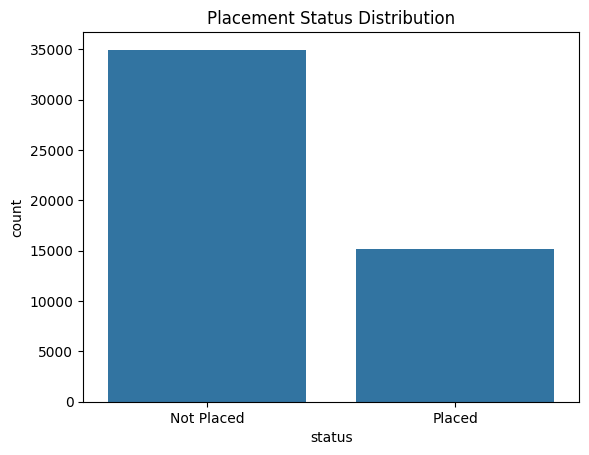

In [82]:
#Target variable distribution
#Check if your target (status) is balanced (Placed / Not Placed):

sns.countplot(x='status', data=jobdata)

plt.title('Placement Status Distribution')
plt.xticks([0,1], ['Not Placed','Placed'])   # Add labels
plt.show()

Explanation:

The target variable status was label encoded where 0 represents "Not Placed" and 1 represents "Placed". A count plot was used to visualize the distribution of placement outcomes.

In [83]:
jobdata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50124 entries, 0 to 51497
Data columns (total 38 columns):
 #   Column                                        Non-Null Count  Dtype   
---  ------                                        --------------  -----   
 0   age_years                                     50124 non-null  int64   
 1   gender                                        50124 non-null  int64   
 2   ssc_percentage                                50124 non-null  float64 
 3   hsc_percentage                                50124 non-null  float64 
 4   degree_percentage                             50124 non-null  float64 
 5   technical_score                               50124 non-null  float64 
 6   aptitude_score                                50124 non-null  float64 
 7   communication_score                           50124 non-null  float64 
 8   skills_match_percentage                       50124 non-null  float64 
 9   certifications_count                          50124 non

Category Columns Still Exist

still we have category dtype columns:
skills_level,experience_level,experience_category,academic_band,interview_level
We have to change numeric values

Becauase of Machine learning models usually require numeric values, not category.

In [84]:
cat_cols = [
    'skills_level',
    'experience_level',
    'experience_category',
    'academic_band',
    'interview_level'
]

for col in cat_cols:
    jobdata[col] = jobdata[col].cat.codes

Null Values in Experience Columns ⚠️

These two columns have missing values:
experience_level,experience_category  

In [85]:
jobdata['experience_level'] = jobdata['experience_level'].replace(-1, 3) # Assuming 3 for 'Unknown' category
jobdata['experience_category'] = jobdata['experience_category'].replace(-1, 3) # Assuming 3 for 'Unknown' category

In [86]:
#Convert bool → int ,Because machine learning models require numeric values.
bool_cols = jobdata.select_dtypes('bool').columns

jobdata[bool_cols] = jobdata[bool_cols].astype(int)

In [87]:
#check info
jobdata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50124 entries, 0 to 51497
Data columns (total 38 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   age_years                                     50124 non-null  int64  
 1   gender                                        50124 non-null  int64  
 2   ssc_percentage                                50124 non-null  float64
 3   hsc_percentage                                50124 non-null  float64
 4   degree_percentage                             50124 non-null  float64
 5   technical_score                               50124 non-null  float64
 6   aptitude_score                                50124 non-null  float64
 7   communication_score                           50124 non-null  float64
 8   skills_match_percentage                       50124 non-null  float64
 9   certifications_count                          50124 non-null  floa

In [88]:
#Cleaned Dataset Save
jobdata_cleaned = jobdata.copy()
jobdata_cleaned.to_csv("jobdata_cleaned.csv", index=False)

In [89]:
jobdata = pd.read_csv("jobdata_cleaned.csv")
jobdata.head()

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,...,interview_avg,interview_level,degree_specialization_electronics,degree_specialization_information technology,degree_specialization_mechanical,degree_specialization_others,company_tier_tier 2,company_tier_tier 3,competition_level_low,competition_level_medium
0,27,1,65.061656,83.842578,75.856526,58.221909,89.566305,64.474484,79.548913,2.0,...,70.754233,1,0,0,0,0,0,1,0,1
1,24,1,67.885626,64.973305,73.093588,71.927978,54.591971,61.077306,73.316134,1.0,...,62.532418,1,1,0,0,0,0,0,0,0
2,33,0,73.892471,68.834121,90.196460,72.445041,58.587088,79.494739,75.466980,1.0,...,70.175622,1,0,1,0,0,0,1,1,0
3,31,1,74.145568,76.255126,75.586731,78.855676,61.022065,53.740386,73.676449,2.0,...,64.539376,1,0,0,1,0,1,0,1,0
4,28,1,60.475937,65.786336,80.801010,68.286776,65.713731,61.438314,88.994847,1.0,...,65.146274,1,0,1,0,0,1,0,0,1


Step 7: Machine Learning Modeling

In [90]:
#Define Target Variable
jobdata['status'].value_counts()

,count
status,
0,34950
1,15174


Data Splitting
Define Features and Target

Separate input features (X) and target (y).

In [91]:
#Split the data
# Separate features and target
X = jobdata.drop("status", axis=1)
y = jobdata["status"]

Explanation

X → input features

y → target variable (Placed / Not Placed)

In [92]:
#Train Test Split
from sklearn.model_selection import train_test_split

In [93]:
#Split the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Explanation

80% → Training data

20% → Testing data

random_state=42 → reproducibility

stratify=y → keeps placed / not placed ratio balanced

Feature Scaling

Scaling helps models understand features that have different ranges.

our dataset has features with different ranges:

technical_score → 0–100

previous_ctc_lpa → maybe 1–20

notice_period_days → up to 90

Machine learning models perform better when features are scaled.

In [94]:
#Apply StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Rule

fit_transform() → only training data

transform() → testing data

In [95]:
#After Scaling → Train Machine Learning Model
#Start with Logistic Regression.
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000)

In [96]:
#Prediction
y_pred = model.predict(X_test_scaled)

In [97]:
#Model Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8693266832917705

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      6990
           1       0.80      0.76      0.78      3035

    accuracy                           0.87     10025
   macro avg       0.85      0.84      0.84     10025
weighted avg       0.87      0.87      0.87     10025


Confusion Matrix
[[6422  568]
 [ 742 2293]]


Model Performance Explanation

The model achieved an accuracy of 86.93%, indicating that it correctly predicted the placement status for most candidates in the test dataset. From the classification report, the model shows strong performance in predicting not placed candidates (precision 0.90, recall 0.92) and good performance for placed candidates (precision 0.80, recall 0.76).

The confusion matrix shows that 6422 not placed candidates and 2293 placed candidates were correctly classified, while a smaller number of cases were misclassified. Overall, the model demonstrates good predictive capability for identifying candidate placement outcomes.

In [98]:
#Now train another model to compare.
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [99]:
#Model evaluate
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 0.8835910224438903
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      6990
           1       0.84      0.75      0.80      3035

    accuracy                           0.88     10025
   macro avg       0.87      0.85      0.86     10025
weighted avg       0.88      0.88      0.88     10025




Model Performance Explanation

The model achieved an accuracy of 88.36%, indicating strong predictive performance in classifying candidate placement status. The classification report shows that the model performs very well in predicting not placed candidates (precision 0.90, recall 0.94) and also shows good performance for placed candidates (precision 0.84, recall 0.75). The F1-scores (0.92 for not placed and 0.80 for placed) indicate a good balance between precision and recall. Overall, the model demonstrates reliable prediction capability for candidate placement outcomes.

In [100]:
#Now train another model to compare.
#Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)


In [101]:
#Model evaluate
from sklearn.metrics import accuracy_score, classification_report

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))


Decision Tree Accuracy: 0.8285286783042394
              precision    recall  f1-score   support

           0       0.88      0.87      0.88      6990
           1       0.71      0.72      0.72      3035

    accuracy                           0.83     10025
   macro avg       0.80      0.80      0.80     10025
weighted avg       0.83      0.83      0.83     10025



Decision Tree Model Explanation

The Decision Tree classifier was used to predict whether a candidate will be placed (1) or not placed (0). The model achieved an accuracy of 82.85%, meaning it correctly predicted the placement status for most candidates in the test dataset. The model shows higher performance in predicting not placed candidates (precision 0.88, recall 0.87) compared to placed candidates (precision 0.71, recall 0.72). Overall, the model demonstrates good predictive capability, but its performance is slightly lower than ensemble models like Random Forest.

In [102]:
#Now train another model to compare.
#Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

In [103]:
#model evaluate
print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))
print(classification_report(y_test, gb_pred))

Gradient Boosting Accuracy: 0.8919700748129675
              precision    recall  f1-score   support

           0       0.91      0.94      0.92      6990
           1       0.84      0.79      0.82      3035

    accuracy                           0.89     10025
   macro avg       0.88      0.86      0.87     10025
weighted avg       0.89      0.89      0.89     10025



Gradient Boosting Model

The Gradient Boosting classifier was implemented to predict whether a candidate will be placed (1) or not placed (0). The model achieved an accuracy of 89.19%, indicating strong predictive performance. The model performs well in identifying not placed candidates (precision 0.91, recall 0.94) and also shows good performance for placed candidates (precision 0.84, recall 0.79). The F1-score values (0.92 for not placed and 0.82 for placed) indicate a good balance between precision and recall. Overall, the Gradient Boosting model demonstrates high accuracy and reliable prediction capability for the job placement dataset.

In [104]:
#Model comparison
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "Gradient Boosting"],
    "Accuracy": [0.8693, 0.8285, 0.8836, 0.8919]
})

comparison.sort_values(by="Accuracy", ascending=False)



,Model,Accuracy
3,Gradient Boosting,0.8919
2,Random Forest,0.8836
0,Logistic Regression,0.8693
1,Decision Tree,0.8285


Explanation

Among the implemented models, Gradient Boosting achieved the highest accuracy (89.19%), followed by Random Forest (88.36%), Logistic Regression (86.93%), and Decision Tree (82.85%). Therefore, Gradient Boosting was selected as the final model for predicting candidate placement status.

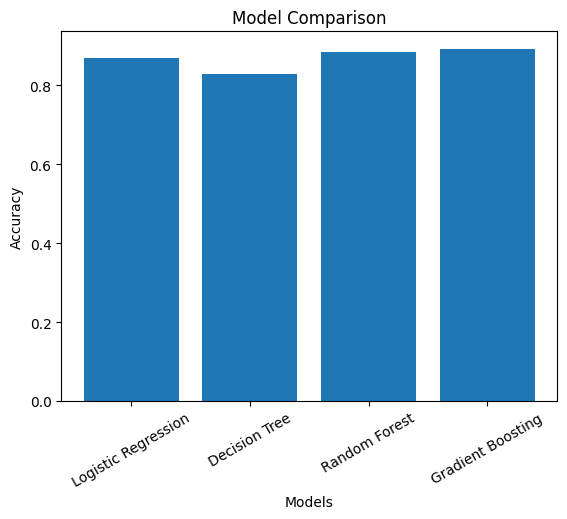

In [105]:
#Visualization
import matplotlib.pyplot as plt

plt.bar(comparison["Model"], comparison["Accuracy"])
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

Insights:

The bar chart compares the accuracy of different machine learning models used to predict candidate placement status. From the visualization, Gradient Boosting achieved the highest accuracy (89.19%), indicating the best predictive performance among all models. Random Forest also performed well with an accuracy of 88.36%, followed by Logistic Regression (86.93%). The Decision Tree model showed the lowest accuracy (82.85%).

This comparison shows that ensemble models such as Gradient Boosting and Random Forest provide better prediction performance, as they combine multiple decision trees and reduce overfitting. Therefore, Gradient Boosting was selected as the final model for predicting candidate placement outcomes.

In [106]:
#Final Model Selection
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Final model
final_model = GradientBoostingClassifier(random_state=42)

# Train the model
final_model.fit(X_train, y_train)

# Predictions
y_pred = final_model.predict(X_test)

# Evaluation
print("Final Model: Gradient Boosting")
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Final Model: Gradient Boosting
Accuracy: 0.8919700748129675

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.94      0.92      6990
           1       0.84      0.79      0.82      3035

    accuracy                           0.89     10025
   macro avg       0.88      0.86      0.87     10025
weighted avg       0.89      0.89      0.89     10025


Confusion Matrix
[[6548  442]
 [ 641 2394]]


Final Model Selection Explain:

Based on the model comparison results, Gradient Boosting achieved the highest accuracy (89.19%) among all the tested models. Therefore, it was selected as the final model for predicting candidate placement status. The model demonstrates strong predictive capability and provides reliable classification results for both placed and not placed candidates.

Step 8 : Analyst Tasks (EDA & ML Analytics)




1️⃣ Candidate Performance Analysis

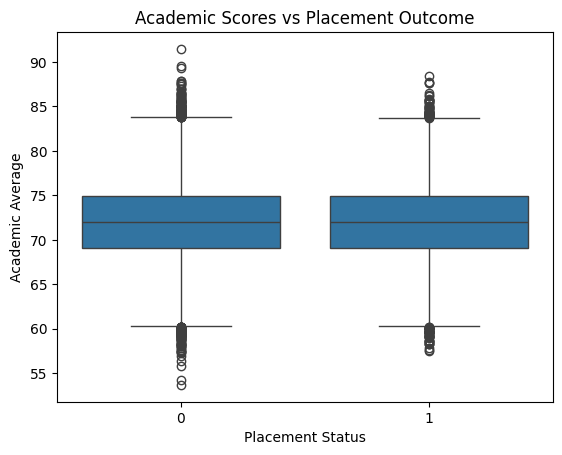

In [107]:
#Academic scores vs placement outcome

sns.boxplot(x='status', y='academic_avg', data=jobdata)
plt.title("Academic Scores vs Placement Outcome")
plt.xlabel("Placement Status")
plt.ylabel("Academic Average")
plt.show()



Insight

The box plot shows that placed candidates (1) have slightly higher academic average scores than not placed candidates (0). However, the score ranges overlap significantly, indicating that many candidates with similar academic scores may or may not be placed.

ML Analytics:

Academic performance contributes to placement prediction, but due to the overlap between the two groups, academic scores alone are not a strong predictor. Machine learning models likely rely more on additional features such as technical skills, interview performance, and experience to improve prediction accuracy.

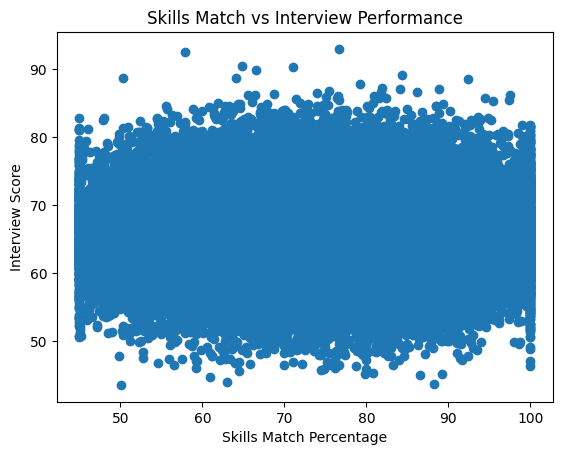

In [108]:
#Skills match vs interview performance
plt.scatter(jobdata['skills_match_percentage'], jobdata['interview_avg'])
plt.title("Skills Match vs Interview Performance")
plt.xlabel("Skills Match Percentage")
plt.ylabel("Interview Score")
plt.show()


Insight (EDA)

The scatter plot shows a slight positive relationship between skills match percentage and interview score. Candidates with higher skill match percentages tend to achieve moderately higher interview scores, although the points are widely scattered.

ML Analytics

This indicates that skills match contributes to interview performance, but the weak correlation suggests that other factors such as communication skills, aptitude score, and experience also influence interview outcomes. Therefore, machine learning models combine multiple features to improve prediction accuracy.

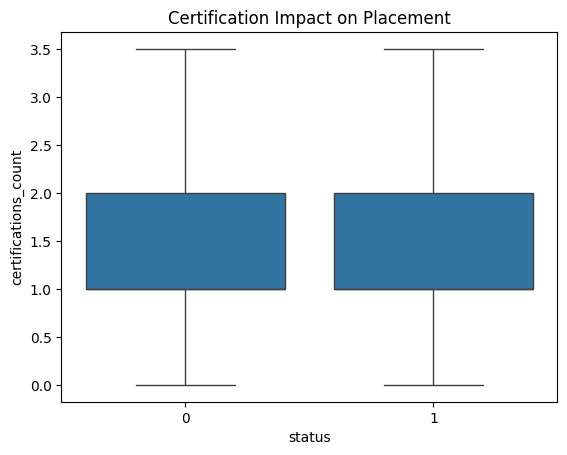

In [109]:
#Certification Impact on Job Acceptance
sns.boxplot(x='status', y='certifications_count', data=jobdata)
plt.title("Certification Impact on Placement")
plt.show()

Insight (EDA)

The box plot shows that the number of certifications for placed (1) and not placed (0) candidates is quite similar, with most candidates having around 1–2 certifications. This indicates that certifications alone do not strongly differentiate placed and not placed candidates.

ML Analytics

From a machine learning perspective, certifications may contribute slightly to placement prediction, but they are not a dominant feature due to the similar distribution across both groups. Other factors such as skills match, interview performance, and technical scores likely have a stronger influence on the model’s predictions.

2️⃣ Placement & Acceptance Analysis

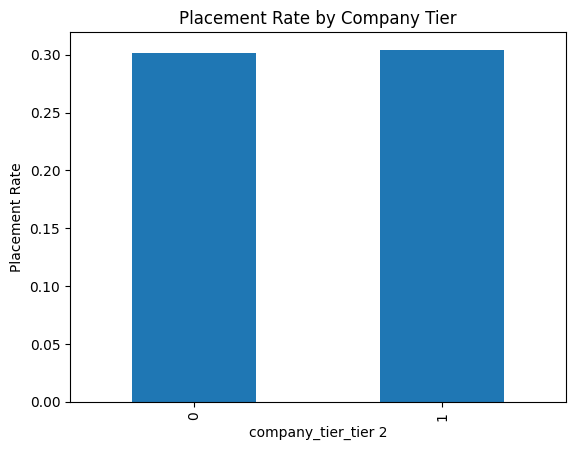

In [110]:
#Acceptance Rate by Company Tier
jobdata.groupby('company_tier_tier 2')['status'].mean().plot(kind='bar')
plt.title("Placement Rate by Company Tier")
plt.ylabel("Placement Rate")
plt.show()

Insight (EDA)

The chart shows that the placement rate is almost similar across both company tiers. Candidates applying to Tier 1 and Tier 2 companies have nearly the same placement probability, around 30%. This indicates that company tier alone does not significantly affect the overall placement rate.

ML Analytics

From a machine learning perspective, company tier may have a moderate influence on placement prediction, but it is not a highly discriminative feature since the placement rates are very close. Other variables such as skills match, interview score, and academic performance are likely more important features for predicting placement outcomes.

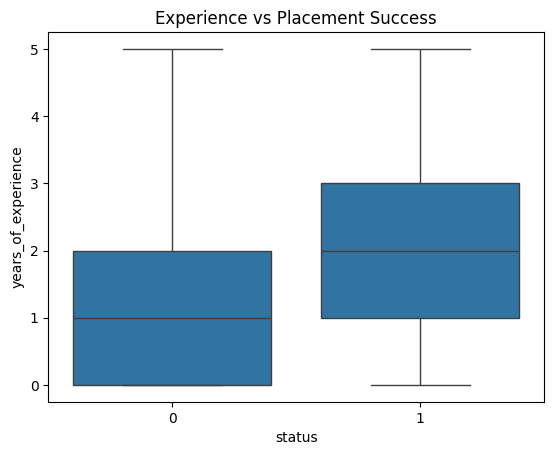

In [111]:
#Experience vs Placement Success
sns.boxplot(x='status', y='years_of_experience', data=jobdata)
plt.title("Experience vs Placement Success")
plt.show()

Insight (EDA)

The box plot shows the relationship between years of experience and placement status. Candidates who are placed (status = 1) tend to have slightly higher or similar experience compared to not placed candidates (status = 0). However, the overlap between both groups suggests that experience alone does not guarantee placement.

ML Analytics

From a machine learning perspective, years_of_experience can be considered a useful predictive feature, but it may not be a dominant factor. The model likely relies on a combination of features such as skills match, interview score, and academic performance along with experience to accurately predict placement outcomes.

3️⃣ Interview & Evaluation Analysis

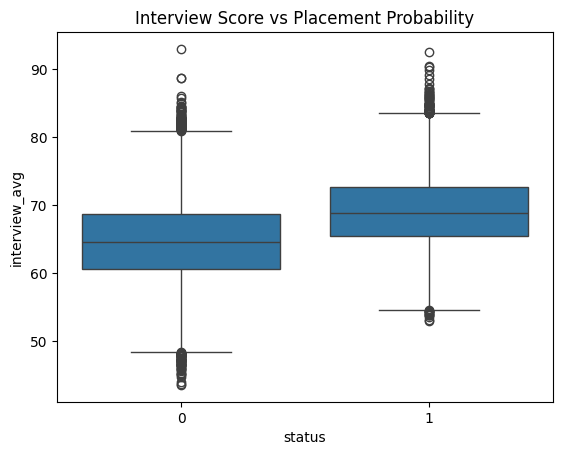

In [112]:
#Interview Score vs Placement Probability
sns.boxplot(x='status', y='interview_avg', data=jobdata)
plt.title("Interview Score vs Placement Probability")
plt.show()

Insight (EDA)

The box plot shows that placed candidates (status = 1) generally have higher interview scores compared to not placed candidates (status = 0). This indicates that candidates who perform well in interviews have a higher probability of getting placed.

ML Analytics

From a machine learning perspective, interview_avg is an important predictive feature for placement prediction. Higher interview scores increase the likelihood of placement, so this feature likely contributes significantly to the model’s decision-making process when predicting job acceptance outcomes.

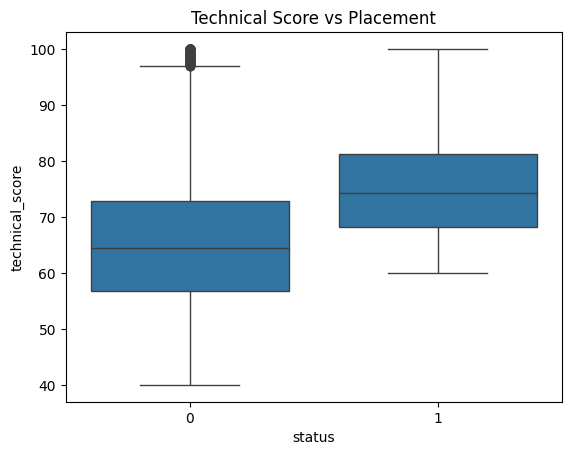

In [113]:
#Employability Test Score Analysis
sns.boxplot(x='status', y='technical_score', data=jobdata)
plt.title("Technical Score vs Placement")
plt.show()

Insight (EDA)

The box plot shows that placed candidates (status = 1) generally have higher technical scores compared to not placed candidates (status = 0). This indicates that better performance in the employability/technical test increases the chances of placement.

ML Analytics

From a machine learning perspective, technical_score is an important feature for predicting placement outcomes. Candidates with higher technical scores are more likely to be predicted as placed, so this feature likely contributes strongly to the model’s prediction performance.

In [114]:
jobdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50124 entries, 0 to 50123
Data columns (total 38 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   age_years                                     50124 non-null  int64  
 1   gender                                        50124 non-null  int64  
 2   ssc_percentage                                50124 non-null  float64
 3   hsc_percentage                                50124 non-null  float64
 4   degree_percentage                             50124 non-null  float64
 5   technical_score                               50124 non-null  float64
 6   aptitude_score                                50124 non-null  float64
 7   communication_score                           50124 non-null  float64
 8   skills_match_percentage                       50124 non-null  float64
 9   certifications_count                          50124 non-null 